
---
date: "2026-08-16"
date-modified: last-modified
format:
  html:
    toc: true
---


# Brownian Motion (The Wiener Process)

**[Brownian motion](brownian-motion.ipynb)** (also known as the **Wiener process**) is the continuous-time analogue of the discrete-time random walk and the foundational building block of continuous stochastic calculus. First observed physically by botanist Robert Brown in 1827 and mathematically formulated by Louis Bachelier (1900), Albert Einstein (1905), and Norbert Wiener (1923), Brownian motion provides the standard model for diffusion phenomena, molecular fluctuations, and financial asset price dynamics.

---


## 1\. From Random Walk to Continuous Time

To build intuition for Brownian motion, consider a classical discrete-time **random walk**.

::: {#def-discrete-random-walk}
## Discrete-Time Random Walk
Let $(Y_k)_{k=1}^\infty$ be a sequence of [independent and identically distributed (i.i.d.) random variables](independence-of-rvs.ipynb) with common distribution $F$, mean $\mathbb{E}[Y_k] = 0$, and finite variance $\text{Var}(Y_k) = \sigma^2$. The process $(X_t)_{t \in \mathbb{N}_0}$ defined by:
$$
X_0 = 0, \qquad X_t = \sum_{k=1}^t Y_k, \quad t = 1, 2, \dots
$$
is a **discrete-time random walk** on $\mathbb{R}$.
:::

For any integer $t$, the variance expands linearly with time:
$$
\text{Var}(X_t) = \text{Var}\left( \sum_{k=1}^t Y_k \right) = \sum_{k=1}^t \text{Var}(Y_k) = \sigma^2 t
$$
Hence, the standard deviation grows at rate $\sigma \sqrt{t}$, creating a parabolic diffusive envelope around the zero mean.

::: {.callout-note}
## Intuition: The Challenge of Continuous-Time Random Steps
A natural question is: *Can we construct a continuous-time random walk by making the time step $dt \to 0$?*

In continuous time $t \in [0, \infty)$, between any two distinct instants $s < t$ there are uncountably many intermediate moments. If we tried to assign independent non-zero step sizes at each instant, the sum of variances would explode to infinity. Conversely, if the variance at each instant were zero, the process would be deterministic.

To resolve this dilemma, we define continuous-time Brownian motion **axiomatically** by specifying the joint probabilistic structure of its increments over finite time intervals.
:::


## 2\. Stationarity and Increments

Before stating the axioms of Brownian motion, we clarify the distinctions between process stationarity, stationary increments, and independent increments.

::: {#def-stationarity}
## Process Stationarity (Strict vs. Weak)
Let $X = (X_t)_{t \in T}$ be a [stochastic process](stochastic-processes-foundations.ipynb) with $T \subseteq \mathbb{R}$:

1. **Strict Stationarity:** $X$ is strictly stationary if for any $n \ge 1$, any time points $t_1, \dots, t_n \in T$, and any shift $h$ such that $t_i + h \in T$:
$$
\left( X_{t_1}, X_{t_2}, \dots, X_{t_n} \right) \stackrel{d}{=} \left( X_{t_1 + h}, X_{t_2 + h}, \dots, X_{t_n + h} \right)
$$
2. **Weak (Covariance) Stationarity:** $X$ is weakly stationary if:
   - Mean is constant over time: $\mu_X(t + h) = \mu_X(t) = \mu$ for all $t, h$.
   - Covariance depends only on the time lag $|t - s|$: $C_X(t + h, s + h) = C_X(t, s) = \gamma(t - s)$.
:::

::: {#def-stationary-increments}
## Stationary Increments
A stochastic process $(X_t)_{t \in T}$ has **stationary increments** if for all $s, t \in T$ and all shift parameters $h$ such that $s+h, t+h \in T$:
$$
X_t - X_s \stackrel{d}{=} X_{t+h} - X_{s+h}
$$
That is, the probability distribution of an increment depends only on the elapsed duration $t - s$, not on the calendar starting time $s$.
:::

::: {#def-independent-increments}
## Independent Increments
A stochastic process $(X_t)_{t \in T}$ has **independent increments** if for every integer $n \ge 2$ and every selection of ordered time indices $t_1 < t_2 < \dots < t_n \in T$, the increment random variables:
$$
X_{t_2} - X_{t_1}, \quad X_{t_3} - X_{t_2}, \quad \dots, \quad X_{t_n} - X_{t_{n-1}}
$$
are mutually [independent random variables](independence-of-rvs.ipynb).
:::


## 3\. Axiomatic Definition of Brownian Motion

We now formulate the standard axiomatic definition of Brownian motion.

::: {#def-standard-brownian-motion}
## Standard Brownian Motion (Wiener Process)
A continuous-time stochastic process $B = (B_t)_{t \ge 0}$ on a [probability space](probability.ipynb) $(\Omega, \mathcal{F}, \mathbb{P})$ is called a **standard Brownian motion** (or **standard Wiener process**) if it satisfies the following four postulates:

1. **Initial Value:** $B_0 = 0$ almost surely.
2. **Independent Increments:** For any ordered time sequence $0 \le t_1 < t_2 < \dots < t_n$, the increments $B_{t_2} - B_{t_1}, B_{t_3} - B_{t_2}, \dots, B_{t_n} - B_{t_{n-1}}$ are mutually independent.
3. **Stationary Gaussian Increments:** For any $0 \le s < t$, the increment $B_t - B_s$ is normally distributed with mean $0$ and variance $t - s$:
$$
B_t - B_s \sim \mathcal{N}(0, \, t - s)
$$
In particular, setting $s = 0$ yields the marginal distribution for all $t > 0$:
$$
B_t \sim \mathcal{N}(0, t)
$$
4. **Continuous Sample Paths:** With probability 1, the sample path function $t \mapsto B_t(\omega)$ is continuous for all $t \ge 0$ (no jumps).
:::

::: {.callout-note}
## Connection between Marginal Distribution and Stationary Increments
By stationary increments (Axiom 3 with $h = -s$):
$$
B_t - B_s \stackrel{d}{=} B_{t-s} - B_0 = B_{t-s}
$$
Since $B_{t-s} \sim \mathcal{N}(0, t - s)$, it follows immediately that $B_t - B_s \sim \mathcal{N}(0, t - s)$. The variance of the increment is precisely equal to the elapsed time interval $\Delta t = t - s$.
:::


## 4\. Moments and the Covariance Kernel

From the axiomatic definition, we can immediately compute the mean function and covariance structure of standard Brownian motion.

::: {#prp-brownian-moments}
## Mean and Covariance Function of Brownian Motion
Let $(B_t)_{t \ge 0}$ be a standard Brownian motion. Then:

1. **Mean Function:** $\mu_B(t) = \mathbb{E}[B_t] = 0$ for all $t \ge 0$.
2. **Increment Variance:** $\text{Var}(B_t - B_s) = t - s$ for all $0 \le s \le t$.
3. **Covariance Kernel:** For all $s, t \ge 0$, the covariance is given by the minimum of the two times:
$$
C_B(s, t) = \text{Cov}\left( B_s, B_t \right) = \min(s, t)
$$
:::

::: {.callout-tip collapse="true"}
## Proof of the Covariance Kernel $C_B(s, t) = \min(s, t)$
Without loss of generality, assume $s \le t$. We decompose $B_t$ into the sum of $B_s$ and the independent increment $(B_t - B_s)$:
$$
B_t = B_s + (B_t - B_s)
$$
Using the bilinearity of covariance:
$$
\begin{aligned}
\text{Cov}(B_s, B_t) &= \text{Cov}\left( B_s, \, B_s + (B_t - B_s) \right) \\
&= \text{Cov}(B_s, B_s) + \text{Cov}\left( B_s, \, B_t - B_s \right) \\
&= \text{Var}(B_s) + \text{Cov}\left( B_s - B_0, \, B_t - B_s \right)
\end{aligned}
$$
Since the intervals $[0, s]$ and $[s, t]$ are disjoint, by Axiom 2 (Independent Increments), the random variables $B_s - B_0$ and $B_t - B_s$ are independent. Independent random variables have zero covariance, so $\text{Cov}(B_s - B_0, B_t - B_s) = 0$.

Substituting $\text{Var}(B_s) = s$:
$$
\text{Cov}(B_s, B_t) = s + 0 = s = \min(s, t)
$$
By symmetry, if $t \le s$, we obtain $\text{Cov}(B_s, B_t) = t = \min(s, t)$. Therefore, for all $s, t \ge 0$:
$$
C_B(s, t) = \min(s, t) \quad \blacksquare
$$
:::


## 5\. Brownian Motion as a Gaussian Process

An equivalent and foundational perspective is to characterize Brownian motion as a member of the [Gaussian process](gaussian-processes.ipynb) family.

::: {#def-gaussian-brownian-motion}
## Gaussian Characterization of Brownian Motion
A standard Brownian motion $(B_t)_{t \ge 0}$ is a [Gaussian process](gaussian-processes.ipynb) with:
- Mean function: $\mu_B(t) = 0$ for all $t \ge 0$.
- Covariance kernel: $C_B(s, t) = \min(s, t)$ for all $s, t \ge 0$.
- Continuous sample paths almost surely.
:::

::: {#thm-brownian-is-gaussian}
## Equivalence Theorem: Axiomatic Definition Implies Gaussian Process
A stochastic process $(B_t)_{t \ge 0}$ satisfying the Axiomatic Definition (Axioms 1–4) is a Gaussian process.
:::

::: {.callout-tip collapse="true"}
## Proof via Linear Transformation of Independent Increments
To prove that $(B_t)_{t \ge 0}$ is a Gaussian process, we must show that for any arbitrary finite collection of time points $0 \le t_1 < t_2 < \dots < t_n$, the random vector $\mathbf{B} = (B_{t_1}, B_{t_2}, \dots, B_{t_n})^T$ has a [multivariate normal distribution](multivariate-normal-distribution.ipynb).

**Step 1: Construct the increment vector.**
Define the increment random variables:
$$
X_1 = B_{t_1} - B_0 = B_{t_1}, \quad X_2 = B_{t_2} - B_{t_1}, \quad X_3 = B_{t_3} - B_{t_2}, \quad \dots, \quad X_n = B_{t_n} - B_{t_{n-1}}
$$
By Axioms 2 and 3, $X_1, X_2, \dots, X_n$ are mutually independent, univariate normal random variables with $X_i \sim \mathcal{N}(0, t_i - t_{i-1})$ (with $t_0 = 0$).

**Step 2: Joint distribution of independent normal variables.**
Recall that a collection of independent normal random variables is jointly multivariate normal. Therefore, the vector $\mathbf{X} = (X_1, X_2, \dots, X_n)^T$ is distributed as:
$$
\mathbf{X} \sim \mathcal{N}\left( \mathbf{0}, \, \mathbf{D} \right), \qquad \mathbf{D} = \text{diag}(t_1, \, t_2 - t_1, \, \dots, \, t_n - t_{n-1})
$$

**Step 3: Invertible linear transformation.**
Notice that the original vector $\mathbf{B}$ is a deterministic linear transformation of the increment vector $\mathbf{X}$:
$$
\begin{aligned}
B_{t_1} &= X_1 \\
B_{t_2} &= X_1 + X_2 \\
B_{t_3} &= X_1 + X_2 + X_3 \\
&\;\;\vdots \\
B_{t_n} &= X_1 + X_2 + \dots + X_n
\end{aligned}
$$
In matrix form, $\mathbf{B} = \mathbf{A} \mathbf{X}$, where $\mathbf{A}$ is the lower triangular matrix of ones:
$$
\mathbf{A} = \begin{pmatrix} 1 & 0 & 0 & \dots & 0 \\ 1 & 1 & 0 & \dots & 0 \\ 1 & 1 & 1 & \dots & 0 \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & 1 & 1 & \dots & 1 \end{pmatrix}
$$
Because any linear transformation of a multivariate normal vector is also multivariate normal, $\mathbf{B} = \mathbf{A} \mathbf{X}$ is multivariate normal with mean $\mathbf{A} \mathbf{0} = \mathbf{0}$ and covariance matrix $\boldsymbol{\Sigma} = \mathbf{A} \mathbf{D} \mathbf{A}^T$.

Since this holds for every choice of $n \ge 1$ and all $t_1 < \dots < t_n$, every finite-dimensional distribution of $(B_t)_{t \ge 0}$ is multivariate normal. Hence, Brownian motion is a Gaussian process. $\blacksquare$
:::


## 6\. Self-Similarity and Brownian Scaling

A defining mathematical property of Brownian motion is its scale invariance or **self-similarity**.

::: {#def-self-similarity}
## $H$-Self-Similar Process
A continuous-time stochastic process $(X_t)_{t \ge 0}$ is called **$H$-self-similar** (with Hurst parameter or scaling exponent $H > 0$) if for every scaling constant $c > 0$, its finite-dimensional distributions satisfy:
$$
\left( X_{c t_1}, X_{c t_2}, \dots, X_{c t_n} \right) \stackrel{d}{=} \left( c^H X_{t_1}, c^H X_{t_2}, \dots, c^H X_{t_n} \right)
$$
Equivalently, the scaled process $(\widetilde{X}_t)_{t \ge 0}$ defined by $\widetilde{X}_t = c^{-H} X_{ct}$ has the same probability law as $(X_t)_{t \ge 0}$.
:::

::: {#prp-brownian-scaling}
## Brownian Scaling Law ($H = 0.5$)
Standard Brownian motion $(B_t)_{t \ge 0}$ is **$0.5$-self-similar** ($H = 1/2$). That is, for any scaling factor $c > 0$, the process:
$$
\widetilde{B}_t = \frac{1}{\sqrt{c}} B_{ct}, \quad t \ge 0
$$
is a standard Brownian motion.
:::

::: {.callout-tip collapse="true"}
## Proof of Brownian Scaling
Let $c > 0$ and define $\widetilde{B}_t = c^{-1/2} B_{ct}$. We verify that $\widetilde{B}$ satisfies the Gaussian characterization of Brownian motion:

1. **Gaussian Process:** Since $\widetilde{B}_t$ is a scaled evaluation of the Gaussian process $B$, all its finite-dimensional distributions are multivariate normal.
2. **Mean Function:**
$$
\mathbb{E}[\widetilde{B}_t] = \frac{1}{\sqrt{c}} \mathbb{E}[B_{ct}] = \frac{1}{\sqrt{c}} \cdot 0 = 0
$$
3. **Covariance Kernel:** For any $s, t \ge 0$:
$$
\begin{aligned}
\text{Cov}(\widetilde{B}_s, \widetilde{B}_t) &= \text{Cov}\left( \frac{1}{\sqrt{c}} B_{cs}, \, \frac{1}{\sqrt{c}} B_{ct} \right) \\
&= \frac{1}{c} \text{Cov}(B_{cs}, B_{ct}) \\
&= \frac{1}{c} \min(cs, ct) = \frac{1}{c} \cdot c \min(s, t) = \min(s, t)
\end{aligned}
$$
4. **Path Continuity:** Since $t \mapsto B_{ct}$ is continuous almost surely, $t \mapsto \widetilde{B}_t$ is continuous almost surely.

Since $\widetilde{B}$ is a Gaussian process with zero mean, covariance $\min(s, t)$, and continuous sample paths, it is a standard Brownian motion. Therefore, Brownian motion is $0.5$-self-similar. $\blacksquare$
:::


## 7\. Path Irregularity: Non-Differentiability and Infinite Variation

While Brownian sample paths are continuous almost everywhere, they exhibit extreme local roughness.

::: {#prp-nowhere-differentiability}
## Nowhere Differentiability
With probability 1, the sample paths of standard Brownian motion $t \mapsto B_t(\omega)$ are **nowhere differentiable** on $[0, \infty)$.
:::

::: {.callout-note}
## Intuition: Divergence of the Difference Quotient
Consider the Newton difference quotient of $B_t$ over a small increment $h > 0$:
$$
\frac{B_{t+h} - B_t}{h} \sim \mathcal{N}\left( 0, \, \frac{h}{h^2} \right) = \mathcal{N}\left( 0, \, \frac{1}{h} \right)
$$
As $h \to 0$, the variance of the difference quotient diverges to infinity ($\text{Var} = 1/h \to \infty$). Consequently, the difference quotient oscillates wildly between $-\infty$ and $+\infty$, preventing the existence of a finite derivative at any point.
:::

::: {#prp-unbounded-variation}
## Unbounded Total Variation
Let $\pi = \{0 = t_0 < t_1 < \dots < t_n = t\}$ denote a partition of the interval $[0, t]$. The **total variation** of Brownian sample paths is almost surely infinite:
$$
\sup_\pi \sum_{i=1}^n |B_{t_i}(\omega) - B_{t_{i-1}}(\omega)| = \infty
$$
where the supremum is taken over all possible finite partitions $\pi$ of $[0, t]$.
:::

::: {.callout-warning}
## Why Ordinary Calculus Fails (and Itô Calculus is Needed)
In classical deterministic calculus, functions must have **bounded variation** to define Riemann-Stieltjes integrals $\int f \, dg$. Because Brownian paths have infinite total variation, classical integration theory cannot be applied pathwise.

However, Brownian motion possesses a finite and deterministic **quadratic variation**:
$$
\lim_{\|\pi\| \to 0} \sum_{i=1}^n (B_{t_i} - B_{t_{i-1}})^2 = t \quad \text{in } L^2
$$
This non-zero quadratic variation is written informally as $(dB_t)^2 = dt$, establishing the foundational calculus rule of **Itô's Lemma**.
:::


## 8\. Python Simulation: Paths, Envelopes, and Self-Similarity

Below, we simulate multiple Brownian paths alongside theoretical diffusion bands, demonstrate $0.5$-self-similarity via time-scaling, and illustrate the explosive variance of the difference quotient.

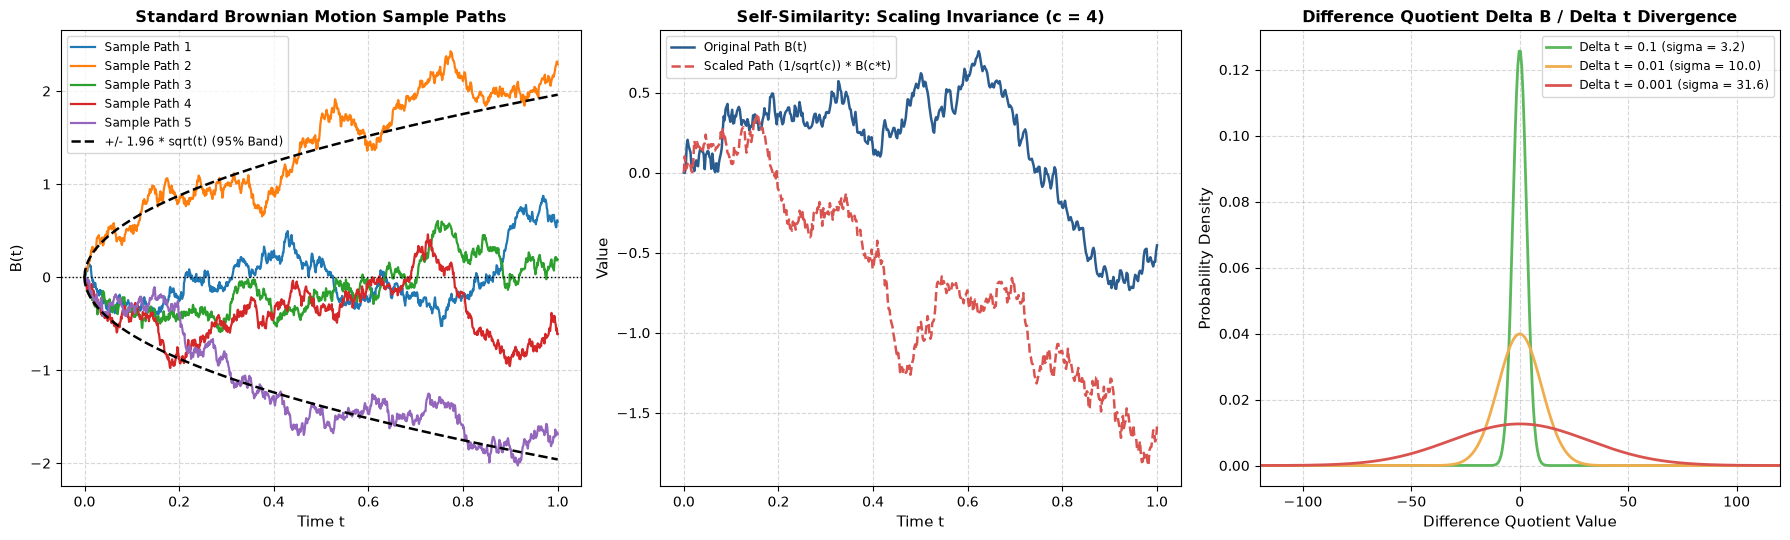

In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1. Standard Brownian Motion Sample Paths and 95% Diffusion Envelope
T_max = 1.0
N = 1000
time_grid = np.linspace(0.0, T_max, N)
dt = T_max / (N - 1)

n_paths = 5
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i in range(n_paths):
    dB = np.random.normal(0, np.sqrt(dt), N - 1)
    B_path = np.zeros(N)
    B_path[1:] = np.cumsum(dB)
    axes[0].plot(time_grid, B_path, lw=1.6, color=colors[i], label=f'Sample Path {i+1}')

# Theoretical 95% Envelope (+- 1.96 * sqrt(t))
envelope = 1.96 * np.sqrt(time_grid)
axes[0].plot(time_grid, envelope, 'k--', lw=1.8, label='+/- 1.96 * sqrt(t) (95% Band)')
axes[0].plot(time_grid, -envelope, 'k--', lw=1.8)
axes[0].axhline(0, color='black', lw=1, linestyle=':')
axes[0].set_title('Standard Brownian Motion Sample Paths', fontsize=11.5, fontweight='bold')
axes[0].set_xlabel('Time t', fontsize=10.5)
axes[0].set_ylabel('B(t)', fontsize=10.5)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper left', fontsize=8.5)

# 2. Self-Similarity (Brownian Scaling Law: c = 4, H = 0.5)
c_scale = 4.0
N_fine = 2000
t_fine = np.linspace(0.0, c_scale, N_fine)
dt_fine = c_scale / (N_fine - 1)
dB_fine = np.random.normal(0, np.sqrt(dt_fine), N_fine - 1)
B_fine = np.zeros(N_fine)
B_fine[1:] = np.cumsum(dB_fine)

# Scaled process: B_tilde(t) = (1/sqrt(c)) * B(c*t) on t in [0, 1]
t_unit = np.linspace(0.0, 1.0, 500)
B_orig_unit = np.interp(t_unit, t_fine, B_fine)
B_scaled_unit = (1.0 / np.sqrt(c_scale)) * np.interp(c_scale * t_unit, t_fine, B_fine)

axes[1].plot(t_unit, B_orig_unit, color='#2b5c8f', lw=1.8, label='Original Path B(t)')
axes[1].plot(t_unit, B_scaled_unit, color='#d9534f', lw=1.8, linestyle='--', label='Scaled Path (1/sqrt(c)) * B(c*t)')
axes[1].set_title('Self-Similarity: Scaling Invariance (c = 4)', fontsize=11.5, fontweight='bold')
axes[1].set_xlabel('Time t', fontsize=10.5)
axes[1].set_ylabel('Value', fontsize=10.5)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper left', fontsize=8.5)

# 3. Path Roughness: Difference Quotient Variance Divergence
h_values = [0.1, 0.01, 0.001]
h_colors = ['#5cb85c', '#f0ad4e', '#d9534f']
x_quotient = np.linspace(-150, 150, 500)

for idx, h in enumerate(h_values):
    std_h = 1.0 / np.sqrt(h)
    pdf_h = (1.0 / (std_h * np.sqrt(2 * np.pi))) * np.exp(-0.5 * (x_quotient / std_h)**2)
    axes[2].plot(x_quotient, pdf_h, lw=2.0, color=h_colors[idx], label=f'Delta t = {h} (sigma = {std_h:.1f})')

axes[2].set_xlim([-120, 120])
axes[2].set_title('Difference Quotient Delta B / Delta t Divergence', fontsize=11.5, fontweight='bold')
axes[2].set_xlabel('Difference Quotient Value', fontsize=10.5)
axes[2].set_ylabel('Probability Density', fontsize=10.5)
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(loc='upper right', fontsize=8.5)

plt.tight_layout()
plt.show()
